# Zing Generation Demo

Generate ZINC samples from a saved `ConditionalNodeFieldGraphGenerator`.

- inspect saved checkpoints
- load one model
- sample with and without feasibility filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import os
import random

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from abstractgraph_graphicalizer.chem import draw_molecules
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)


PyTorch version: 2.5.0+cpu
CUDA available: False


In [2]:
MODEL_FILENAME = 'zinc15-nonstreaming-d64-s0-99-b128-e350.pkl'
#MODEL_FILENAME = 'zinc15-streaming-d64-s0-5-w256-b8-e256.pkl'
#MODEL_FILENAME = 'zinc18-streaming-d64-s0-9-w2049-b128-e256.pkl'
N_SAMPLES = 7

DECODER_VERBOSE = 1
DECODER_EXISTENCE_THRESHOLD = 0.5
DECODER_ENFORCE_CONNECTIVITY = True
DECODER_DEGREE_SLACK_PENALTY = 1e6
DECODER_WARM_START_MST = True
DECODER_N_JOBS = -1
DECODER_GRAPH_RENDERER = draw_molecules

USE_FEASIBILITY_FILTERING = True
MAX_FEASIBILITY_ATTEMPTS = 5
FEASIBILITY_CANDIDATES_PER_ATTEMPT = 2
FEASIBILITY_FAILURE_MODE = 'return_partial'
MAX_FEASIBILITY_SECONDS_PER_SAMPLE = 10.0
FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT = 1
MAX_ORACLE_ITERATIONS = 4
ORACLE_USE_NODE_LABEL_CUTS = True
ORACLE_USE_EDGE_LABEL_CUTS = True
RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [3]:
list_saved_graph_generators(SAVED_GENERATOR_ROOT)

graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)
graph_generator.graph_decoder.verbose = DECODER_VERBOSE
graph_generator.graph_decoder.existence_threshold = DECODER_EXISTENCE_THRESHOLD
graph_generator.graph_decoder.enforce_connectivity = DECODER_ENFORCE_CONNECTIVITY
graph_generator.graph_decoder.degree_slack_penalty = DECODER_DEGREE_SLACK_PENALTY
graph_generator.graph_decoder.warm_start_mst = DECODER_WARM_START_MST
graph_generator.graph_decoder.n_jobs = DECODER_N_JOBS
graph_generator.graph_decoder.diagnostic_graph_renderer = DECODER_GRAPH_RENDERER
graph_generator.use_feasibility_filtering = USE_FEASIBILITY_FILTERING
graph_generator.max_feasibility_attempts = MAX_FEASIBILITY_ATTEMPTS
graph_generator.feasibility_candidates_per_attempt = FEASIBILITY_CANDIDATES_PER_ATTEMPT
graph_generator.feasibility_failure_mode = FEASIBILITY_FAILURE_MODE
graph_generator.max_feasibility_seconds_per_sample = MAX_FEASIBILITY_SECONDS_PER_SAMPLE
graph_generator.feasibility_oracle_candidates_per_attempt = FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT
graph_generator.max_oracle_iterations = MAX_ORACLE_ITERATIONS
graph_generator.oracle_use_node_label_cuts = ORACLE_USE_NODE_LABEL_CUTS
graph_generator.oracle_use_edge_label_cuts = ORACLE_USE_EDGE_LABEL_CUTS


,name,modified,size_mb
0,zinc18-streaming-d64-s0-9-w2049-b128-e256.pkl,2026-04-02 14:27,36.1
1,zinc15-nonstreaming-d64-s0-99-b128-e350.pkl,2026-04-02 14:27,176.1
2,zinc15-streaming-d64-s0-5-w256-b8-e256.pkl,2026-04-02 04:54,8.1
3,artificial-d32-n86-size8.pkl,2026-03-24 19:40,4.4


Loaded graph generator: zinc15-nonstreaming-d64-s0-99-b128-e350.pkl
/home/fabrizio/code/NodeField/.artifacts/saved_generators/zinc15-nonstreaming-d64-s0-99-b128-e350.pkl


In [4]:
print('Loaded graph generator =', getattr(graph_generator, 'model_name', MODEL_FILENAME))
print('Decoder verbose =', graph_generator.graph_decoder.verbose)
print('Decoder existence_threshold =', graph_generator.graph_decoder.existence_threshold)
print('Decoder enforce_connectivity =', graph_generator.graph_decoder.enforce_connectivity)
print('Decoder degree_slack_penalty =', graph_generator.graph_decoder.degree_slack_penalty)
print('Decoder warm_start_mst =', graph_generator.graph_decoder.warm_start_mst)
print('Decoder n_jobs =', graph_generator.graph_decoder.n_jobs)
print('Decoder graph renderer =', getattr(graph_generator.graph_decoder.diagnostic_graph_renderer, '__name__', graph_generator.graph_decoder.diagnostic_graph_renderer))
print('Feasibility estimator available =', graph_generator.feasibility_estimator is not None)
print('use_feasibility_filtering =', graph_generator.use_feasibility_filtering)
print('max_feasibility_attempts =', graph_generator.max_feasibility_attempts)
print('feasibility_candidates_per_attempt =', graph_generator.feasibility_candidates_per_attempt)
print('feasibility_failure_mode =', graph_generator.feasibility_failure_mode)
print('max_feasibility_seconds_per_sample =', graph_generator.max_feasibility_seconds_per_sample)
print('feasibility_oracle_candidates_per_attempt =', graph_generator.feasibility_oracle_candidates_per_attempt)
print('max_oracle_iterations =', graph_generator.max_oracle_iterations)
print('oracle_use_node_label_cuts =', graph_generator.oracle_use_node_label_cuts)
print('oracle_use_edge_label_cuts =', graph_generator.oracle_use_edge_label_cuts)


Loaded graph generator = zinc15-nonstreaming-d64-s0-99-b128-e350
Decoder verbose = 1
Decoder existence_threshold = 0.5
Decoder enforce_connectivity = True
Decoder degree_slack_penalty = 1000000.0
Decoder warm_start_mst = True
Decoder n_jobs = -1
Decoder graph renderer = draw_molecules
Feasibility estimator available = True
use_feasibility_filtering = True
max_feasibility_attempts = 5
feasibility_candidates_per_attempt = 2
feasibility_failure_mode = return_partial
max_feasibility_seconds_per_sample = 10.0
feasibility_oracle_candidates_per_attempt = 1
max_oracle_iterations = 4
oracle_use_node_label_cuts = True
oracle_use_edge_label_cuts = True


Sampling 7 graphs
Zing generation samples without feasibility filtering


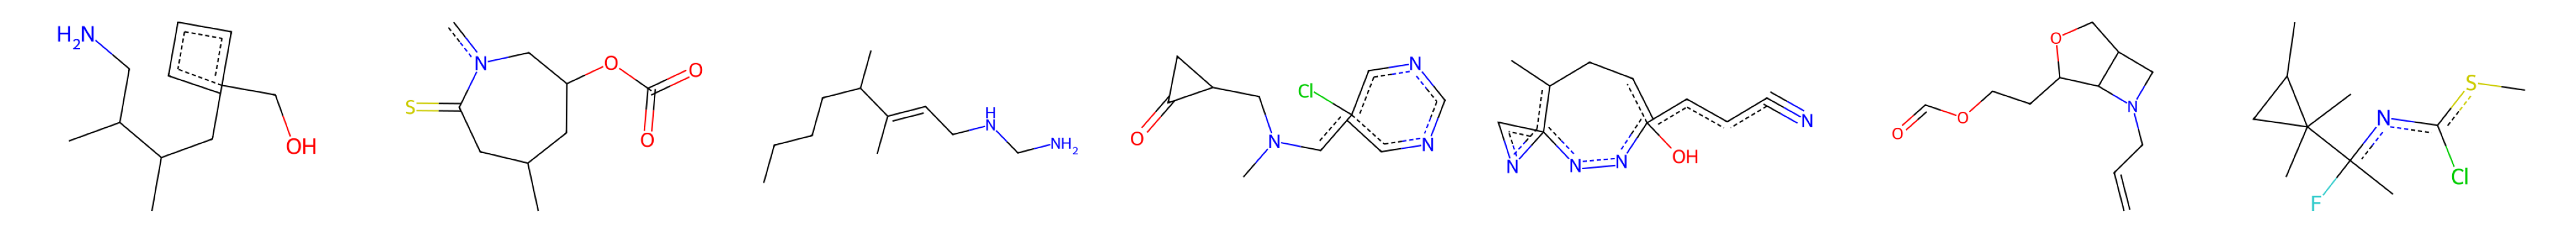

In [5]:
raw_samples = graph_generator.sample(
    n_samples=N_SAMPLES,
    apply_feasibility_filtering=False,
)
show_molecules(raw_samples, n=N_SAMPLES, title='Zing generation samples without feasibility filtering')


In [ ]:
if graph_generator.feasibility_estimator is None:
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

graph_generator.feasibility_rejection_mode = "fallback_unfiltered"  # or "strict"

filtered_samples = graph_generator.sample(
    n_samples=N_SAMPLES,
    apply_feasibility_filtering=True,
)
show_molecules(filtered_samples, n=N_SAMPLES, title='Zing generation samples with feasibility filtering')


Sampling 7 graphs
Feasibility attempt  1/5  | generated=   2 | feasible_candidates= 1 | feasible_rate= 50.0% | attempt_time=   44.2s | eta=    0.0s
Feasibility filtering summary: generated=2, feasible_candidates=1, feasible_rate=50.0%, fulfilled_slots=1/1.
Feasibility attempt  1/5  | generated=   2 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=   18.3s | eta=1m 13.4s
Feasibility attempt  2/5  | generated=   2 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=    4.4s | eta=   34.2s
Feasibility attempt  3/5  | generated=   2 | feasible_candidates= 1 | feasible_rate= 50.0% | attempt_time=    5.6s | eta=    0.0s
Feasibility filtering summary: generated=6, feasible_candidates=1, feasible_rate=16.7%, fulfilled_slots=1/1.
Feasibility attempt  1/5  | generated=   2 | feasible_candidates= 1 | feasible_rate= 50.0% | attempt_time=1m 26.4s | eta=    0.0s
Feasibility filtering summary: generated=2, feasible_candidates=1, feasible_rate=50.0%, fulfilled_slots=1/1.
Feasi